## __Phase 4c: Open-set evaluation (Phase 2)__

Evaluates whether the matching pipeline can correctly identify RF points that have **no true matching AIS track**, instead of always force-picking a best candidate. This is a separate notebook from `04_evaluation.ipynb` / `05_baseline_comparison.ipynb`, which stay closed-set only (true track always force-included); this notebook reuses the same prefilter/scoring functions and the `scripts/evaluation/metrics.py` shared module, but drives them without the closed-set bypass.

**2a** — diagnostic check of whether the true AIS track would survive prefiltering on its own merits.
**2b** — leave-one-out negatives: for every RF point, its true AIS track is excluded from the candidate pool entirely, and the unbypassed pipeline is rerun. Built by `scripts/modeling/AIS_RF_open_set/AIS_RF_leave_one_out.py` (checkpointed, like the closed-set preselection/scoring scripts).
**2c** — accept/reject threshold analysis (ROC/PR/AUC), tiered by whether any candidate survived prefiltering at all.

### __Import packages__

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

from scripts.evaluation.metrics import (
    summarize_ranking,
    recall_at_k,
    mean_reciprocal_rank,
    stratified_ranking_metrics,
)

### __Load data__

In [2]:
# Select which RF bearing-error model's data to evaluate (must match the
# --error-model used to generate/run the upstream scripts)
ERROR_MODEL = "uniform"  # "uniform" or "gaussian"

DATA_DIR = (
    "../../AIS_RF_matching/data/processed" if ERROR_MODEL == "uniform"
    else f"../../AIS_RF_matching/data/processed/{ERROR_MODEL}"
)

# (display name, closed-set results file, leave-one-out results file,
# score column, "max"/"min")
MODELS = [
    ("PHMM Forward",
     "AIS_RF_forward_scores_data.pkl", "AIS_RF_forward_scores_leaveoneout_data.pkl",
     "normalized_forward_score", "max"),
    ("NN Euclidean",
     "AIS_RF_nn_baseline_euclidean_scores_data.pkl", "AIS_RF_nn_baseline_euclidean_scores_leaveoneout_data.pkl",
     "nn_distance", "min"),
    ("NN Haversine",
     "AIS_RF_nn_baseline_haversine_scores_data.pkl", "AIS_RF_nn_baseline_haversine_scores_leaveoneout_data.pkl",
     "nn_distance", "min"),
    ("NN Segment",
     "AIS_RF_nn_baseline_segment_scores_data.pkl", "AIS_RF_nn_baseline_segment_scores_leaveoneout_data.pkl",
     "nn_distance", "min"),
    ("NN Time-weighted",
     "AIS_RF_nn_baseline_time_weighted_scores_data.pkl", "AIS_RF_nn_baseline_time_weighted_scores_leaveoneout_data.pkl",
     "nn_distance", "min"),
]

# Closed-set (Phase 1): true track always present as a candidate
df_preselection = pd.read_pickle(f"{DATA_DIR}/AIS_RF_preselection_data.pkl")
closed_results = {
    name: pd.read_pickle(f"{DATA_DIR}/{closed_file}")
    for name, closed_file, _, _, _ in MODELS
}

# Open-set (Phase 2): true track excluded from the candidate pool entirely
df_preselection_loo = pd.read_pickle(f"{DATA_DIR}/AIS_RF_preselection_leaveoneout_data.pkl")
loo_results = {
    name: pd.read_pickle(f"{DATA_DIR}/{loo_file}")
    for name, _, loo_file, _, _ in MODELS
}

# 2a diagnostic (computed once by check_true_match_prefilter_recall, see below)
df_true_match_diagnostic = pd.read_pickle(f"{DATA_DIR}/true_match_prefilter_diagnostic.pkl")

### __2a: True prefilter recall (diagnostic)__

For every labeled positive RF point, checks whether its true AIS track would survive all 3 prefilter stages *without* the `compute_alignments` bypass that force-includes it. Computed once by `check_true_match_prefilter_recall()` in `scripts/modeling/AIS_RF_preselection/AIS_RF_preselection.py` — a diagnostic-only function that does not touch the main pipeline. This is the ceiling on end-to-end recall regardless of scoring method: no scoring method can recover a true match that the prefilter itself would have dropped.

In [3]:
true_prefilter_recall = df_true_match_diagnostic["passed_prefilter"].mean()

print(f"True prefilter recall: {true_prefilter_recall:.4f}")
print(f"({df_true_match_diagnostic['passed_prefilter'].sum()} / {len(df_true_match_diagnostic)} true tracks would pass stages 1-3 unaided)")
df_true_match_diagnostic["passed_prefilter"].value_counts()

True prefilter recall: 1.0000
(17081 / 17081 true tracks would pass stages 1-3 unaided)


passed_prefilter
True    17081
Name: count, dtype: int64

On this dataset every true track passes the prefilter unaided (recall = 1.0): RF observations are generated from their own AIS track's positions with bearing error, so they are always within the time/space window of that track. The bypass therefore never actually changes which RF points get a chance at the true match — it only matters for *scoring/ranking* (Phase 1), not for prefilter recall. This also means the leave-one-out negatives built below always remove a candidate that would genuinely have survived prefiltering, which is the correct/intended leave-one-out construction.

### __Flag: does the true-match bypass produce different candidate rows than a normal, filtered candidate?__

Checked explicitly (see notebooks 04/05 and the accompanying write-up): the bypass branch and the normal 3-stage-filtered branch in `compute_alignments` emit rows with the identical 4-column schema (`RF_signal_id`, `RF_track_id`, `AIS_track_id`, `is_true_match`). Downstream, both the PHMM Forward scorer (`AIS_RF_forward_alignment.py`) and the NN baselines (`AIS_RF_nn_baseline.py`) re-fetch full AIS/RF sequences from `df_train` by ID — they never read anything from the preselection dataframe beyond the 3 ID columns. So there is **no schema or behavior mismatch** between bypass and normal candidates; nothing needed patching.

### __2b: Leave-one-out negative construction — summary__

For every RF point, its true AIS track is excluded from the candidate pool entirely (not merely un-bypassed — `compute_alignments(include_true_match=False)` skips it before any prefilter stage runs), then the unbypassed 3-stage prefilter is rerun against every other track. Built once by `scripts/modeling/AIS_RF_open_set/AIS_RF_leave_one_out.py`. Two outcomes:\n- **zero candidates survive** → correct rejection "for free", no scoring involved (Tier 1 below)\n- **1+ candidates survive** → scored below and used as false-match samples (Tier 2 below)\n\nThis is method-independent — it is purely a property of the prefilter, not of PHMM Forward vs. any NN variant — so it is computed once here rather than per method.

In [4]:
rf_universe = df_preselection[["RF_signal_id", "RF_track_id"]].drop_duplicates()
loo_surviving = df_preselection_loo[["RF_signal_id", "RF_track_id"]].drop_duplicates()

n_universe = len(rf_universe)
n_tier1 = n_universe - len(loo_surviving)
n_tier2 = len(loo_surviving)

print(f"Total RF points (universe): {n_universe}")
print(f"Tier 1 — zero candidates survived leave-one-out prefilter (free correct rejection): "
      f"{n_tier1} ({n_tier1 / n_universe:.2%})")
print(f"Tier 2 — 1+ candidates survived, need score/margin thresholding: "
      f"{n_tier2} ({n_tier2 / n_universe:.2%})")

Total RF points (universe): 17081
Tier 1 — zero candidates survived leave-one-out prefilter (free correct rejection): 10985 (64.31%)
Tier 2 — 1+ candidates survived, need score/margin thresholding: 6096 (35.69%)


### __2c: Rejection metrics and threshold analysis__

Builds, per method, a combined positive/negative frame for accept/reject analysis:\n- **Positives** = closed-set RF points (Phase 1 data, true track present as a candidate)\n- **Negatives** = leave-one-out RF points (Phase 2b): Tier 1 (zero candidates — assigned the theoretical worst possible accept-score, since "zero candidates" is itself an unconditional, maximally confident rejection at every threshold) plus Tier 2 (scored candidates)\n\n`accept_score` orients each method's top-1 score so **higher always means more likely a genuine match** (raw score for max-is-better PHMM Forward, negated distance for min-is-better NN variants). `accept_margin` does the same for the top1-vs-runner-up margin, with single-candidate groups (no runner-up to compare against) treated as maximally confident (`+inf`) — honest, since a margin-based rule structurally cannot flag those cases; any weakness there is expected to show up as a lower margin-based AUC than the raw-score AUC.

In [5]:
KEY_COLS = ["RF_track_id", "RF_signal_id", "AIS_track_id", "is_true_match"]


def _fill_inf_with_sentinel(series):
    """
    Replace +-inf placeholders with finite values just beyond the real
    range of the column, so downstream sklearn ROC/PR functions (which
    reject inf/NaN) still treat them as more extreme than every genuine
    score, without changing the ROC/PR/AUC result
    """
    finite = series[np.isfinite(series)]
    return series.replace({
        -np.inf: finite.min() - 1 if len(finite) else -1.0,
        np.inf: finite.max() + 1 if len(finite) else 1.0,
    })


def build_open_set_frame(model_name, closed_file, loo_file, score_col, mode):
    """
    Combined positive (closed-set) / negative (leave-one-out) per-RF-point
    frame for one scoring method's accept/reject analysis

    Args:
        model_name (str): Display name, used to look up closed_results/loo_results
        closed_file, loo_file (str): Unused here, kept for parity with MODELS rows
        score_col (str): Column holding each candidate's score
        mode (str): "max" if a higher score is better, "min" if a lower score is better

    Returns:
        pd.DataFrame: one row per RF point, columns candidate_count,
        top1_score, margin, label (1 = should-accept/positive,
        0 = should-reject/negative), tier ("positive", "tier1", "tier2"),
        accept_score, accept_margin
    """
    closed_merged = df_preselection.merge(closed_results[model_name], on=KEY_COLS, how="inner")
    pos_summary = summarize_ranking(closed_merged, score_col, mode=mode)
    pos_summary["label"] = 1
    pos_summary["tier"] = "positive"

    loo_merged = df_preselection_loo.merge(loo_results[model_name], on=KEY_COLS, how="inner")
    tier2 = summarize_ranking(loo_merged, score_col, mode=mode)
    tier2["label"] = 0
    tier2["tier"] = "tier2"

    scored_points = tier2[["RF_signal_id", "RF_track_id"]]
    tier1 = rf_universe.merge(scored_points, on=["RF_signal_id", "RF_track_id"], how="left", indicator=True)
    tier1 = tier1[tier1["_merge"] == "left_only"][["RF_signal_id", "RF_track_id"]].copy()
    tier1["candidate_count"] = 0
    tier1["top1_score"] = np.nan
    tier1["margin"] = np.nan
    tier1["label"] = 0
    tier1["tier"] = "tier1"

    combined = pd.concat([pos_summary, tier2, tier1], ignore_index=True)

    sign = 1 if mode == "max" else -1
    combined["accept_score"] = np.where(
        combined["top1_score"].notna(), sign * combined["top1_score"], -np.inf
    )
    combined["accept_margin"] = np.select(
        [combined["candidate_count"] == 0, combined["margin"].isna()],
        [-np.inf, np.inf],
        default=combined["margin"],
    )
    # ROC/PR helpers (sklearn) reject +-inf; fold the placeholders into
    # finite sentinels just beyond each column's real range instead
    combined["accept_score"] = _fill_inf_with_sentinel(combined["accept_score"])
    combined["accept_margin"] = _fill_inf_with_sentinel(combined["accept_margin"])
    return combined


open_set_frames = {
    name: build_open_set_frame(name, closed_file, loo_file, score_col, mode)
    for name, closed_file, loo_file, score_col, mode in MODELS
}

#### _Score comparability across methods_\nThe PHMM Forward score is already length-normalized (`normalized_forward_score`, divided by AIS sequence length) and computed independently per (RF point, candidate) pair, so its threshold is directly comparable across candidates. NN distances are already on a fixed absolute scale (kilometers), independent of track length or candidate count. Neither needs extra rescaling, but the two families are **not on the same scale as each other** (log-probability vs. kilometers) — so ROC/AUC below is reported independently per method rather than by pooling raw thresholds across methods.

#### _Overall ROC and PR curves (all leave-one-out negatives, raw score)_

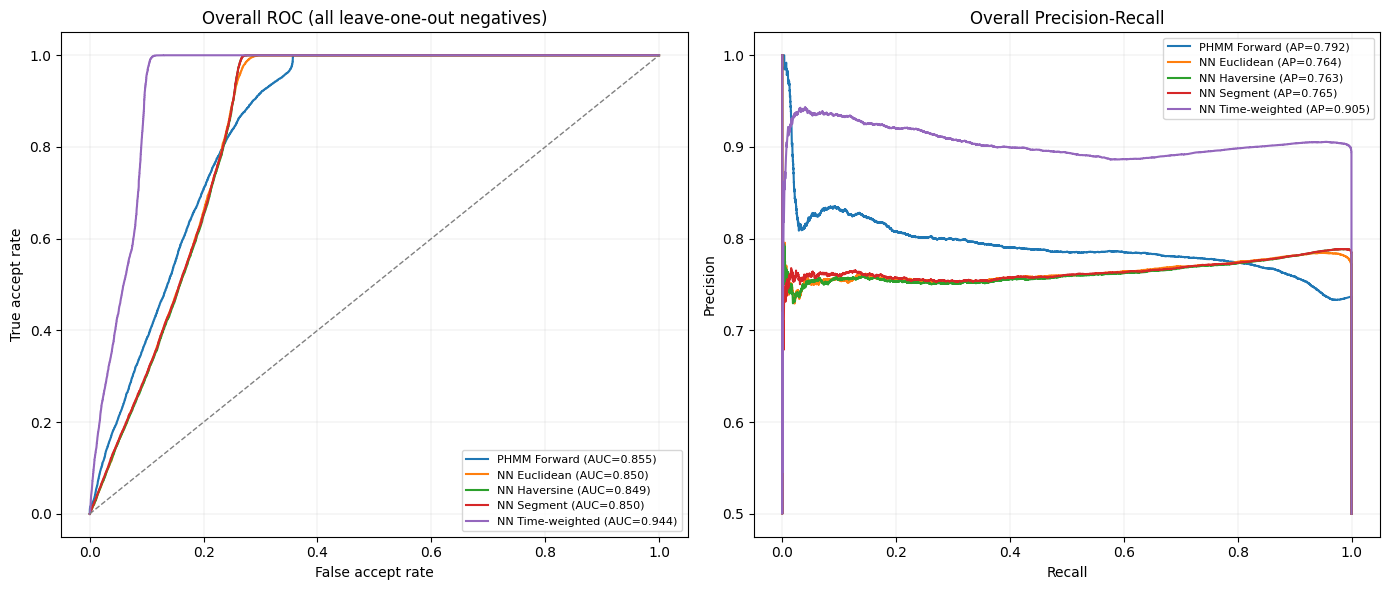

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

auc_rows = []
for name, _, _, _, mode in MODELS:
    frame = open_set_frames[name]
    fpr, tpr, _ = roc_curve(frame["label"], frame["accept_score"])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

    precision, recall, _ = precision_recall_curve(frame["label"], frame["accept_score"])
    ap = average_precision_score(frame["label"], frame["accept_score"])
    axes[1].plot(recall, precision, label=f"{name} (AP={ap:.3f})")

    auc_rows.append({"model": name, "auc_overall_raw": roc_auc, "ap_overall_raw": ap})

axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[0].set_xlabel("False accept rate")
axes[0].set_ylabel("True accept rate")
axes[0].set_title("Overall ROC (all leave-one-out negatives)")
axes[0].legend(fontsize=8)
axes[0].grid(True, linewidth=0.15)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Overall Precision-Recall")
axes[1].legend(fontsize=8)
axes[1].grid(True, linewidth=0.15)

plt.tight_layout()
plt.show()

#### _Tier 2-only ROC (harder subset: at least one candidate survived leave-one-out prefiltering)_

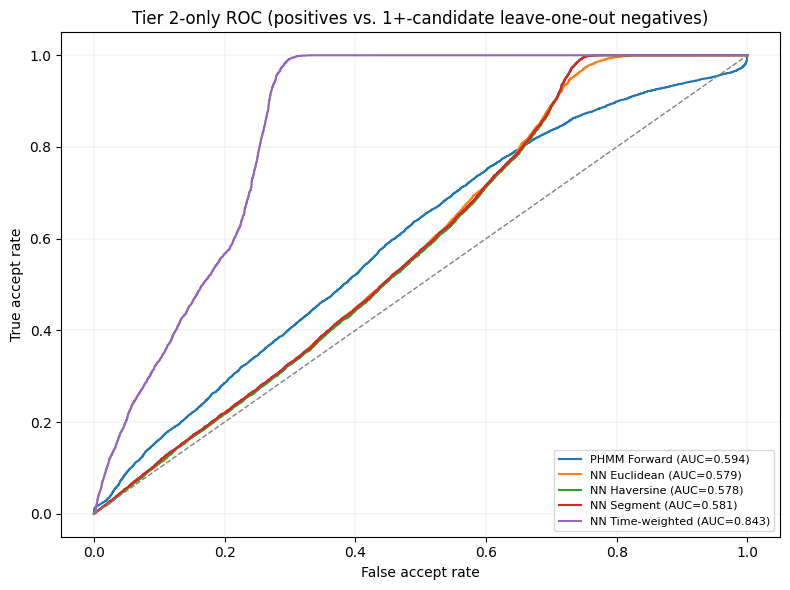

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

tier2_auc_rows = []
for name, _, _, _, mode in MODELS:
    frame = open_set_frames[name]
    tier2_frame = frame[frame["tier"] != "tier1"]
    fpr, tpr, _ = roc_curve(tier2_frame["label"], tier2_frame["accept_score"])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    tier2_auc_rows.append({"model": name, "auc_tier2_raw": roc_auc})

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
ax.set_xlabel("False accept rate")
ax.set_ylabel("True accept rate")
ax.set_title("Tier 2-only ROC (positives vs. 1+-candidate leave-one-out negatives)")
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.15)
plt.tight_layout()
plt.show()

#### _Score margin as an alternative reject signal_

In [8]:
margin_auc_rows = []
for name, _, _, _, mode in MODELS:
    frame = open_set_frames[name]
    tier2_frame = frame[frame["tier"] != "tier1"]

    fpr_m, tpr_m, _ = roc_curve(frame["label"], frame["accept_margin"])
    auc_overall_margin = auc(fpr_m, tpr_m)

    fpr_m2, tpr_m2, _ = roc_curve(tier2_frame["label"], tier2_frame["accept_margin"])
    auc_tier2_margin = auc(fpr_m2, tpr_m2)

    margin_auc_rows.append({
        "model": name,
        "auc_overall_margin": auc_overall_margin,
        "auc_tier2_margin": auc_tier2_margin,
    })

open_set_summary = (
    pd.DataFrame(auc_rows)
    .merge(pd.DataFrame(tier2_auc_rows), on="model")
    .merge(pd.DataFrame(margin_auc_rows), on="model")
)
open_set_summary["tier1_catch_rate"] = n_tier1 / n_universe
open_set_summary = open_set_summary[[
    "model", "tier1_catch_rate",
    "auc_overall_raw", "auc_overall_margin",
    "auc_tier2_raw", "auc_tier2_margin",
    "ap_overall_raw",
]]
open_set_summary

,model,tier1_catch_rate,auc_overall_raw,auc_overall_margin,auc_tier2_raw,auc_tier2_margin,ap_overall_raw
0,PHMM Forward,0.643112,0.855104,0.832453,0.594001,0.530534,0.791686
1,NN Euclidean,0.643112,0.849916,0.834016,0.579464,0.534912,0.763608
2,NN Haversine,0.643112,0.849453,0.834004,0.578167,0.534878,0.762725
3,NN Segment,0.643112,0.850426,0.833980,0.580895,0.534811,0.764771
4,NN Time-weighted,0.643112,0.944068,0.834677,0.843277,0.536765,0.904705


### __Combined Phase 1 + Phase 2 summary__

Side-by-side view of closed-set ranking quality (Phase 1) and open-set rejection quality (Phase 2) per method. Computed fresh in this notebook via the same shared `scripts/evaluation/metrics.py` functions used in `04_evaluation.ipynb` / `05_baseline_comparison.ipynb` — the underlying data and notebooks stay separate, only the metric functions are shared.

In [9]:
closed_set_rows = []
for name, closed_file, _, score_col, mode in MODELS:
    merged = df_preselection.merge(closed_results[name], on=KEY_COLS, how="inner")
    summary = summarize_ranking(merged, score_col, mode=mode)
    closed_set_rows.append({
        "model": name,
        "recall@1": recall_at_k(summary, ks=(1,))[1],
        "mrr": mean_reciprocal_rank(summary),
    })

combined_summary = pd.DataFrame(closed_set_rows).merge(open_set_summary, on="model")
combined_summary

,model,recall@1,mrr,tier1_catch_rate,auc_overall_raw,auc_overall_margin,auc_tier2_raw,auc_tier2_margin,ap_overall_raw
0,PHMM Forward,0.891341,0.941109,0.643112,0.855104,0.832453,0.594001,0.530534,0.791686
1,NN Euclidean,0.826767,0.903611,0.643112,0.849916,0.834016,0.579464,0.534912,0.763608
2,NN Haversine,0.826357,0.903526,0.643112,0.849453,0.834004,0.578167,0.534878,0.762725
3,NN Segment,0.825830,0.903226,0.643112,0.850426,0.833980,0.580895,0.534811,0.764771
4,NN Time-weighted,0.929278,0.963205,0.643112,0.944068,0.834677,0.843277,0.536765,0.904705
